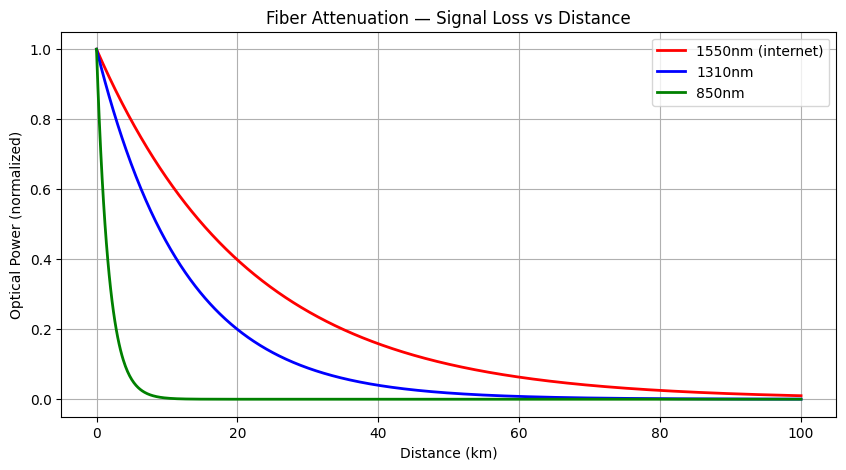

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Fiber attenuation
# আলো দূরে গেলে কতটা দুর্বল হয়

distance = np.linspace(0, 100, 1000)  # 0 to 100 km

# Attenuation coefficient
# 1550nm এ = 0.2 dB/km (সবচেয়ে কম)
# 1310nm এ = 0.35 dB/km
# 850nm এ = 2.5 dB/km

alpha_1550 = 0.2   # dB/km
alpha_1310 = 0.35
alpha_850 = 2.5

# Power calculation
# P(z) = P0 × 10^(-alpha × z / 10)
P0 = 1.0  # initial power

P_1550 = P0 * 10**(-alpha_1550 * distance / 10)
P_1310 = P0 * 10**(-alpha_1310 * distance / 10)
P_850 = P0 * 10**(-alpha_850 * distance / 10)

plt.figure(figsize=(10, 5))
plt.plot(distance, P_1550, 'r-', linewidth=2, label='1550nm (internet)')
plt.plot(distance, P_1310, 'b-', linewidth=2, label='1310nm')
plt.plot(distance, P_850, 'g-', linewidth=2, label='850nm')
plt.title("Fiber Attenuation — Signal Loss vs Distance")
plt.xlabel("Distance (km)")
plt.ylabel("Optical Power (normalized)")
plt.legend()
plt.grid(True)
plt.show()

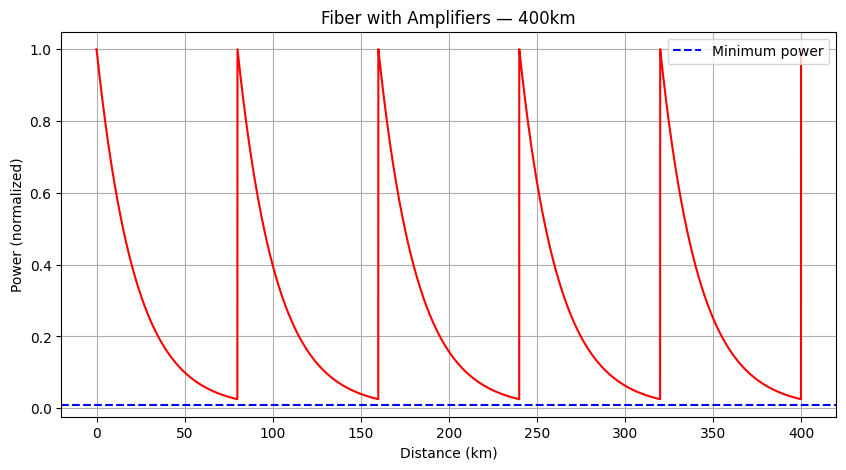

In [3]:
# Fixed version
distance2 = np.linspace(0, 400, 10000)
P = np.zeros(len(distance2))
P[0] = 1.0

for i in range(1, len(distance2)):
    d_step = distance2[i] - distance2[i-1]
    P[i] = P[i-1] * 10**(-alpha_1550 * d_step / 10)
    
    # Amplifier — exactly attenuation compensate করে
    if abs(distance2[i] % amp_spacing) < 0.05:
        P[i] = 1.0  # reset to original power

plt.figure(figsize=(10, 5))
plt.plot(distance2, P, 'r-', linewidth=1.5)
plt.axhline(y=0.01, color='blue', linestyle='--', label='Minimum power')
plt.title("Fiber with Amplifiers — 400km")
plt.xlabel("Distance (km)")
plt.ylabel("Power (normalized)")
plt.legend()
plt.grid(True)
plt.show()